In [129]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

from torchinfo import summary

from going_modular import data_setup, engine

torch.__version__, torchvision.__version__

('2.11.0+cpu', '0.26.0+cpu')

In [130]:
# Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else "cpu"
device

'cpu'

In [131]:
from pathlib import Path

data_dir = Path('data/pizza_sushi_steak/')

train_dir = data_dir / 'train'
test_dir = data_dir / 'test'

train_dir, test_dir

(WindowsPath('data/pizza_sushi_steak/train'),
 WindowsPath('data/pizza_sushi_steak/test'))

## 1. Create Datasets and DataLoaders

### 1.1 Using manual creation

In [132]:
# Setup ImageNet normalization level
from torchvision import transforms

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

manual_transforms = transforms.Compose(
    [transforms.Resize((224, 224)), transforms.ToTensor(), normalize]
)

manual_transforms

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [133]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloader(train_dir=train_dir,
                                                                              test_dir=test_dir,
                                                                              transform=manual_transforms,
                                                                              batch_size=32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1e4dff9c5a0>,
 ['pizza', 'steak', 'sushi'])

### 1.2 Create auto creation

In [134]:
# Get a set of pretrained model weights
weights = torchvision.models.ResNet101_Weights.DEFAULT
weights

ResNet101_Weights.IMAGENET1K_V2

In [135]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [136]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloader(train_dir=train_dir,
                                                                              test_dir=test_dir,
                                                                              transform=auto_transforms,
                                                                              batch_size=32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1e4dff9c9e0>,
 ['pizza', 'steak', 'sushi'])

## 2. Get, Freeze, Train a pretrained model

In [137]:
model = torchvision.models.resnet101(weights=weights).to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### 2.1 Summary of model

In [138]:
from torchinfo import summary

summary(model=model,
        input_size=(32, 3, 224, 224),
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        row_settings=['var_names'])
        

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
ResNet (ResNet)                          [32, 3, 224, 224]         [32, 1000]                --                        True
├─Conv2d (conv1)                         [32, 3, 224, 224]         [32, 64, 112, 112]        9,408                     True
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]        [32, 64, 112, 112]        128                       True
├─ReLU (relu)                            [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential (layer1)                    [32, 64, 56, 56]          [32, 256, 56, 56]         --                        True
│    └─Bottleneck (0)                    [32, 64, 56, 56]          [32, 256, 56, 56]         --                        True
│    │ 

### 2.2 Freeze model

In [139]:
# Freeze all base layer
for param in model.parameters():
    param.requires_grad = False

In [140]:
summary(model=model,
        input_size=(32, 3, 224, 224),
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        row_settings=['var_names'])

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
ResNet (ResNet)                          [32, 3, 224, 224]         [32, 1000]                --                        False
├─Conv2d (conv1)                         [32, 3, 224, 224]         [32, 64, 112, 112]        (9,408)                   False
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]        [32, 64, 112, 112]        (128)                     False
├─ReLU (relu)                            [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential (layer1)                    [32, 64, 56, 56]          [32, 256, 56, 56]         --                        False
│    └─Bottleneck (0)                    [32, 64, 56, 56]          [32, 256, 56, 56]         --                        False
│ 

In [141]:
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [142]:
# Change fc layer of model
model.fc = nn.Linear(in_features=2048, out_features=len(class_names))

In [143]:
summary(model=model,
        input_size=(32, 3, 224, 224),
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        row_settings=['var_names'])

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
ResNet (ResNet)                          [32, 3, 224, 224]         [32, 3]                   --                        Partial
├─Conv2d (conv1)                         [32, 3, 224, 224]         [32, 64, 112, 112]        (9,408)                   False
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]        [32, 64, 112, 112]        (128)                     False
├─ReLU (relu)                            [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential (layer1)                    [32, 64, 56, 56]          [32, 256, 56, 56]         --                        False
│    └─Bottleneck (0)                    [32, 64, 56, 56]          [32, 256, 56, 56]         --                        False


## 3. Train a single model and track results

In [144]:
# Define loss function optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [145]:
# Setup a SummaryWriter
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()
writer

In [146]:
from going_modular.engine import train_step, test_step
from tqdm.auto import tqdm


def train(model: torch.nn.Module,
            train_dataloader: torch.utils.data.DataLoader,
            test_dataloader: torch.utils.data.DataLoader,
            optimizer: torch.optim.Optimizer,
            loss_fn: torch.nn.Module,
            epochs: int=5,
            device=device):

    results = {"train_loss": [],
                "train_acc": [],
                "test_loss": [],
                "test_acc": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        device=device)

        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)
        print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

        results['train_loss'].append(train_loss)
        results['train_acc'].append(train_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)


        ### New: Experiment tracking
        writer.add_scalars(main_tag="Loss",
                           tag_scalar_dict={'train_loss': train_loss,
                                            'test_loss': test_loss},
                           global_step=epoch)
        writer.add_scalars(main_tag='Accuracy',
                           tag_scalar_dict={'train_acc': train_acc,
                                            'test_acc': test_acc},
                           global_step=epoch)
        
        writer.add_graph(model=model,
                         input_to_model=torch.randn(32, 3, 224, 224).to(device))
        
        # Close the writer
        writer.close()
        ### END New
    
    return results

In [147]:
# Train model
results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.0178 | Train acc: 0.5078 | Test loss: 0.9204 | Test acc: 0.7547


 20%|██        | 1/5 [00:47<03:11, 47.76s/it]

Epoch: 1 | Train loss: 0.7943 | Train acc: 0.6641 | Test loss: 0.8028 | Test acc: 0.7860


 40%|████      | 2/5 [01:40<02:31, 50.41s/it]

...

 60%|██████    | 3/5 [02:32<01:42, 51.20s/it]

Epoch: 3 | Train loss: 0.5423 | Train acc: 0.9570 | Test loss: 0.6419 | Test acc: 0.8456


 80%|████████  | 4/5 [03:08<00:45, 45.47s/it]

Epoch: 4 | Train loss: 0.5146 | Train acc: 0.8086 | Test loss: 0.6161 | Test acc: 0.8153


100%|██████████| 5/5 [03:48<00:00, 45.70s/it]


## 4. View model's results with TensorBoard

In [148]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 30108), started 3:32:58 ago. (Use '!kill 30108' to kill it.)

## 5. Create a function to prepare a `SummaryWriter()` instance

`runs/YYY-MM-DD/model_name/extra`

In [165]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from pathlib import Path

def create_writer(model_name: str,
                  extra: str = None):
    timestamp = datetime.now().strftime('%Y-%m-%d')

    if extra:
        # Create log directory path
        log_dir = Path('runs')  / model_name / extra
    else:
        log_dir = Path('runs')  / model_name 

    print(f"[INFO] Create SummaryWriter saving to {log_dir}")
    return SummaryWriter(log_dir=log_dir)
    

In [166]:
example_writer = create_writer(model_name='resnet101',
                               extra='5_epochs')
example_writer

[INFO] Create SummaryWriter saving to runs\resnet101\5_epochs


### 5.1 Update train function  to include  writer parameter

In [167]:
from going_modular.engine import train_step, test_step
from tqdm.auto import tqdm


def train(model: torch.nn.Module,
            train_dataloader: torch.utils.data.DataLoader,
            test_dataloader: torch.utils.data.DataLoader,
            optimizer: torch.optim.Optimizer,
            loss_fn: torch.nn.Module,
            epochs: int,
            writer: torch.utils.tensorboard.SummaryWriter,
            device=device):

    results = {"train_loss": [],
                "train_acc": [],
                "test_loss": [],
                "test_acc": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        device=device)

        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)
        print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

        results['train_loss'].append(train_loss)
        results['train_acc'].append(train_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)


        ### New: Experiment tracking
        if writer:
            writer.add_scalars(main_tag="Loss",
                            tag_scalar_dict={'train_loss': train_loss,
                                                'test_loss': test_loss},
                            global_step=epoch)
            writer.add_scalars(main_tag='Accuracy',
                            tag_scalar_dict={'train_acc': train_acc,
                                                'test_acc': test_acc},
                            global_step=epoch)
            
            writer.add_graph(model=model,
                            input_to_model=torch.randn(32, 3, 224, 224).to(device))
            
            # Close the writer
            writer.close()
        else:
            pass
        ### END New
    
    return results

## 6. Setting up a series of modelling experiments

In [168]:
def create_model(class_names: list):
    model = torchvision.models.resnet101(weights).to(device)
    
    # Freeze all base layer
    for param in model.parameters():
        param.requires_grad = False
    
    model.fc = nn.Linear(in_features=2048, out_features=len(class_names))

    return model

In [169]:
# Define the list of training epochs
num_epochs = [5, 10]

# Define the list of learning rates to explore
learning_rates = [0.001, 0.0005]

# (Optional) Define a list of model architectures to use
# models = ['resnet101', 'resnet151']

# Additional configurations can be added below


In [170]:
from going_modular import utils

# Initialize experiment counter
experiment_number = 0

# Iterate over different epoch configurations
for epochs in num_epochs:
    
    # Iterate over different learning rate configurations
    for lr in learning_rates:
        
        # (Optional) Iterate over different model architectures
        # for model_name in models:

        # Update experiment counter and print experiment metadata
        experiment_number += 1
        print(f"[INFO] Experiment number: {experiment_number}")
        print(f"[INFO] Training with epochs={epochs}, lr={lr}")
        
        # Creaet model 
        model = create_model(class_names)

        # Create fresh loss function and optimizer for each experiment
        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(
            params=model.parameters(),
            lr=lr
        )
        # Run a full training experiment
        train(
            model=model,
            train_dataloader=train_dataloader,
            test_dataloader=test_dataloader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            epochs=epochs,
            device=device,
            writer=create_writer(
                model_name='resnet101',
                extra=f'{epochs}_epochs_{lr}_lr'
            )
        )

        # Save model checkpoint for this configuration
        save_filepath = f"07_resnet101_{epochs}_epochs_{lr}_lr.pth"
        utils.save_model(model=model,
                         target_dir='models',
                         model_name=save_filepath)
        
        print("-"*50, '\n')

        


[INFO] Experiment number: 1
[INFO] Training with epochs=5, lr=0.001
[INFO] Create SummaryWriter saving to runs\resnet101\5_epochs_0.001_lr


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.0306 | Train acc: 0.5469 | Test loss: 0.9081 | Test acc: 0.6932


 20%|██        | 1/5 [00:33<02:15, 33.89s/it]

Epoch: 1 | Train loss: 0.7911 | Train acc: 0.7930 | Test loss: 0.8340 | Test acc: 0.7547


...

Epoch: 8 | Train loss: 0.5325 | Train acc: 0.9531 | Test loss: 0.7244 | Test acc: 0.8248


 90%|█████████ | 9/10 [05:13<00:34, 34.78s/it]

Epoch: 9 | Train loss: 0.5083 | Train acc: 0.8320 | Test loss: 0.6708 | Test acc: 0.8561


100%|██████████| 10/10 [05:48<00:00, 34.82s/it]

[INFO] Saving model to: models\07_resnet101_10_epochs_0.0005_lr.pth
-------------------------------------------------- 



## 7. View experiment in TensorBoard

In [171]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 30108), started 4:00:45 ago. (Use '!kill 30108' to kill it.)

The best performing model was:
* Model: resnet101
* Epoch: 10
* Lr: 0.001
* Model_path: 

## 8. Load in the best model and make predictions with it

In [172]:
best_model_path = r"models\07_resnet101_10_epochs_0.001_lr.pth"

best_model = create_model(class_names)

# Load the saved best model state_dict()
best_model.load_state_dict(torch.load(best_model_path))

c:\Users\mahdi\Desktop\programming\homework\env\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


<All keys matched successfully>

In [177]:
# Check the model file size
from pathlib import Path

# Get the size in byte
resnet101_model_size = Path(best_model_path).stat().st_size // (1024 * 1024)
print(f"Resnet101 feature extractor model size: {resnet101_model_size} MB")

Resnet101 feature extractor model size: 162 MB


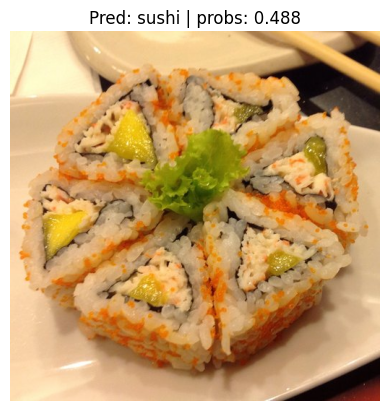

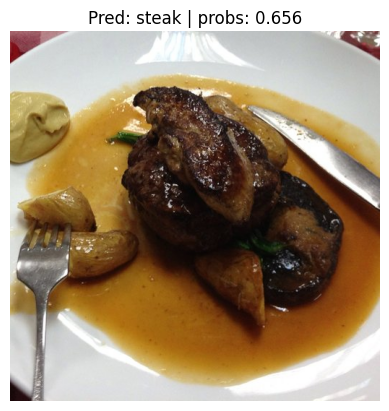

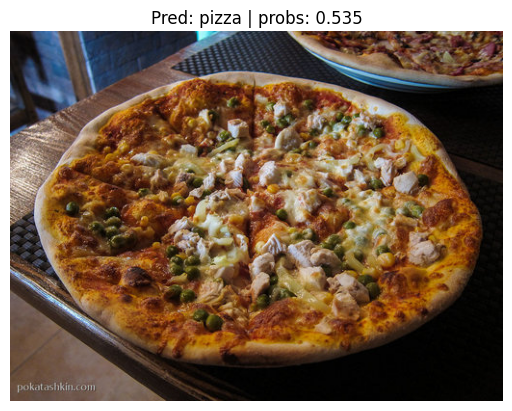

In [187]:
# Import function to make prediction on images and plot 
from going_modular import prediction

# Get a random list of 3 image path names from the test dataset
import random
num_images = 3
test_image_path_list = list(test_dir.glob('*/*.jpg'))
test_image_path_sample = random.sample(test_image_path_list,
                                       k=num_images)
for image_path in test_image_path_sample:
    prediction.pred_plot_image(model=best_model,
                               image_path=image_path,
                               class_names=class_names,
                               image_size=(224,224))

### 8.1 Predict on a custon image

In [189]:
custom_image_path = Path("data/04_dad_pizza.jpeg")
custom_image_path

WindowsPath('data/04_dad_pizza.jpeg')

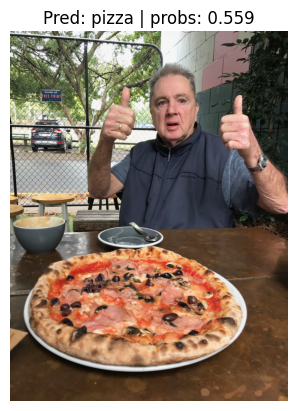

In [190]:
prediction.pred_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names,
                    image_size=(224, 224))